In [18]:
from pathlib import Path
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import Markdown, display
from matplotlib.ticker import MaxNLocator

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (
        candidate
        for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
        if (candidate / "modules").is_dir() and (candidate / "pipelines").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("No se pudo ubicar el repo root desde el cwd actual")

SCENARIO_DIR = CURRENT_DIR
if not (SCENARIO_DIR / "contact_plan_2.json").exists():
    scenario_candidate = REPO_ROOT / "scenarios" / "four_planes_polar"
    if not scenario_candidate.exists():
        raise RuntimeError("No se pudo ubicar el directorio del escenario four_planes_polar")
    SCENARIO_DIR = scenario_candidate

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modules.security.models import SecurityModelType
from pipelines.routing import CGRYenRouting
from pipelines.simulation import SimulationPipeline


SERIES_COLORS = {
    SecurityModelType.HOP_BY_HOP: "#0f4c5c",
    SecurityModelType.END_TO_END: "#e36414",
    SecurityModelType.EDGE_BY_EDGE: "#6a994e",
    SecurityModelType.EDGE_TO_EDGE: "#8d0801",
}

max_routes = 10
pipeline = SimulationPipeline()

result = pipeline.run(
    cp_path=str(SCENARIO_DIR / "contact_plan_2.json"),
    topology_path=str(SCENARIO_DIR / "topology.json"),
    security_models=tuple(SecurityModelType),
    curr_time=0,
    routing_algorithm=CGRYenRouting(max_routes=max_routes)
)

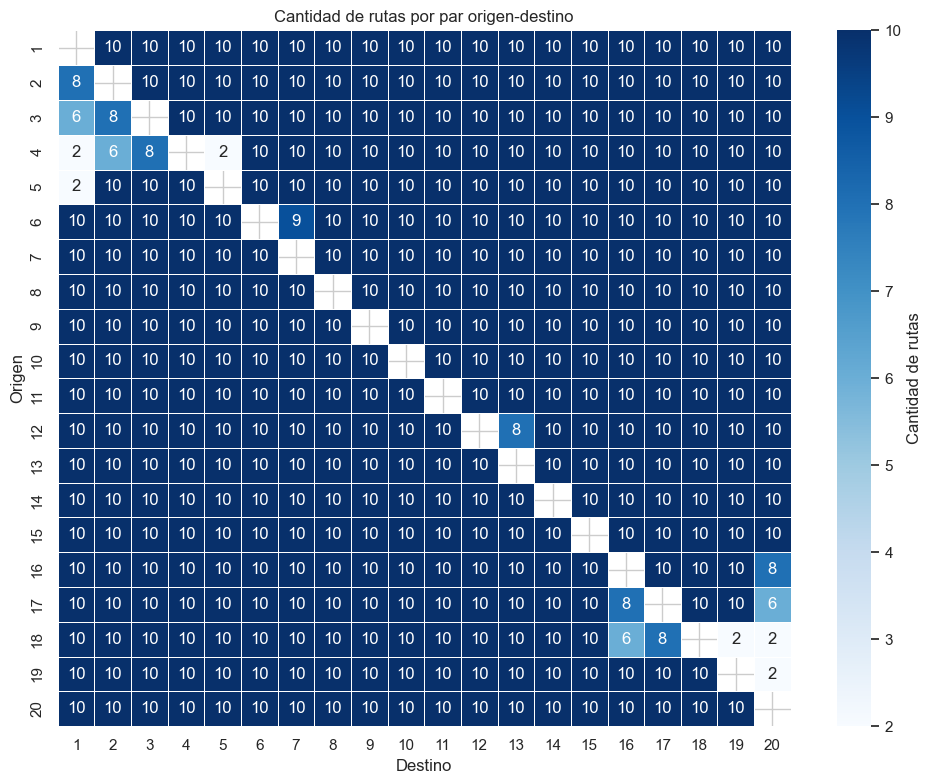

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df_routes = pd.DataFrame(
    [
        {
            "source": source,
            "destination": destination,
            "pair": f"{source}->{destination}",
            "route_count": len(routes),
        }
        for (source, destination), routes in result.routing.routes_by_pair.items()
    ]
).sort_values(["source", "destination"]).reset_index(drop=True)

# display(df_routes)
# display(df_routes["route_count"].value_counts().sort_index().rename_axis("route_count").to_frame("num_pairs"))

matrix = df_routes.pivot(
    index="source",
    columns="destination",
    values="route_count",
)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    matrix,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Cantidad de rutas"},
)

ax.set_title("Cantidad de rutas por par origen-destino")
ax.set_xlabel("Destino")
ax.set_ylabel("Origen")

plt.tight_layout()
plt.show()

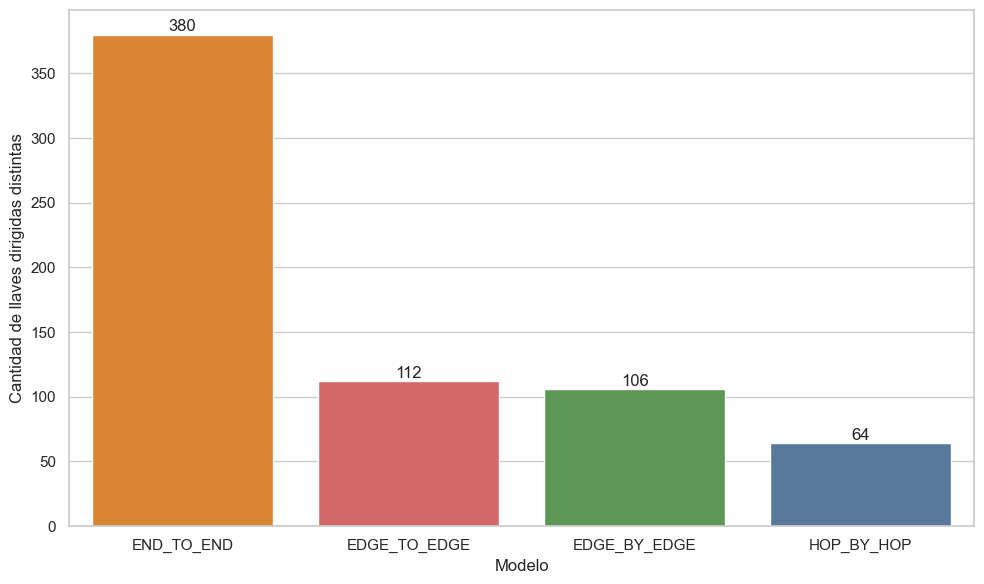

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from modules.security.models import SecurityModelType
from pipelines.route_activation import RouteActivationPlanner

sns.set_theme(style="whitegrid")

MODEL_PALETTE = {
    "HOP_BY_HOP": "#4c78a8",
    "END_TO_END": "#f58518",
    "EDGE_BY_EDGE": "#54a24b",
    "EDGE_TO_EDGE": "#e45756",
}

planner = RouteActivationPlanner()

rows = []
for model in SecurityModelType:
    planning = planner.build_for_model(result.security, model=model)
    rows.append(
        {
            "model": model.name,
            "unique_keys": len(planning.key_scopes),
        }
    )

df = pd.DataFrame(rows).sort_values("unique_keys", ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df,
    x="model",
    y="unique_keys",
    hue="model",
    dodge=False,
    palette=MODEL_PALETTE,
    legend=False,
)
ax.set_ylabel("Cantidad de llaves dirigidas distintas")
ax.set_xlabel("Modelo")

for i, value in enumerate(df["unique_keys"]):
    ax.text(i, value + 0.3, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

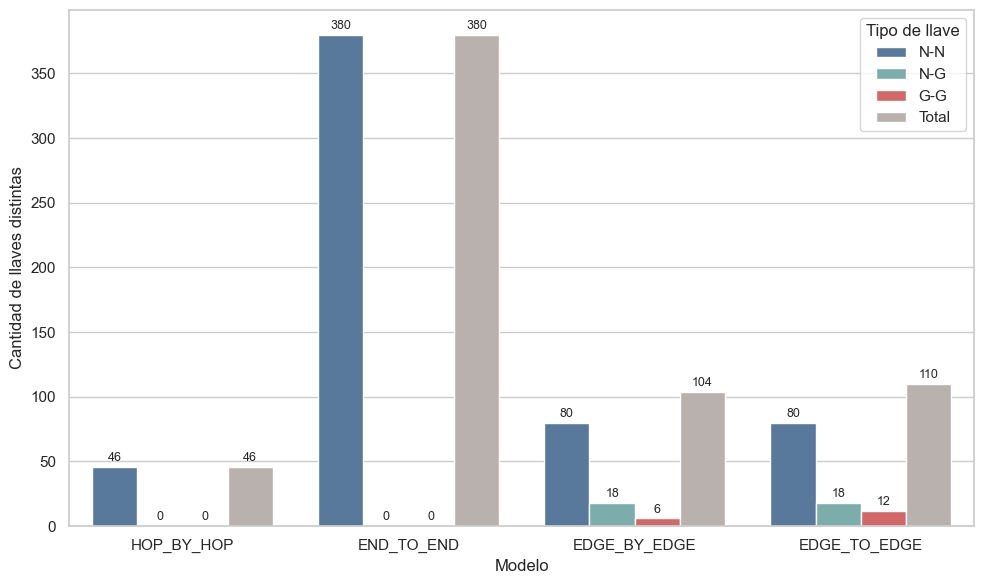

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from modules.security.models import SecurityModelType, KeyType
from pipelines.route_activation import RouteActivationPlanner

sns.set_theme(style="whitegrid")

MODEL_PALETTE = {
    "HOP_BY_HOP": "#4c78a8",
    "END_TO_END": "#f58518",
    "EDGE_BY_EDGE": "#54a24b",
    "EDGE_TO_EDGE": "#e45756",
}

KEY_TYPE_ORDER = ["N-N", "N-G", "G-G", "Total"]

planner = RouteActivationPlanner()

rows = []
for model in SecurityModelType:
    planning = planner.build_for_model(result.security, model=model)
    key_scopes = planning.key_scopes

    counts = {
        "N-N": sum(1 for scope in key_scopes if scope.key_type == KeyType.NODE_TO_NODE),
        "N-G": sum(1 for scope in key_scopes if scope.key_type == KeyType.NODE_TO_GROUP),
        "G-G": sum(1 for scope in key_scopes if scope.key_type == KeyType.GROUP_TO_GROUP),
    }
    counts["Total"] = len(key_scopes)

    for key_type_label in KEY_TYPE_ORDER:
        rows.append(
            {
                "model": model.name,
                "key_type": key_type_label,
                "count": counts[key_type_label],
            }
        )

df = pd.DataFrame(rows)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df,
    x="model",
    y="count",
    hue="key_type",
    hue_order=KEY_TYPE_ORDER,
    palette=["#4c78a8", "#72b7b2", "#e45756", "#bab0ac"],
)

ax.set_ylabel("Cantidad de llaves distintas")
ax.set_xlabel("Modelo")
ax.legend(title="Tipo de llave")

for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=9)

plt.tight_layout()
plt.show()


In [14]:
import pandas as pd

from modules.security.models import SecurityModelType, KeyType

def unique_scopes_by_model(sim_result, model_type):
    return {
        req.scope
        for pair in sim_result.security.pairs
        for plan in sim_result.security.plans_by_model[model_type][pair]
        for req in plan.key_requirements
    }

def format_scope(scope):
    return f"G{scope.source_id}->G{scope.target_id}"

ebe_scopes = unique_scopes_by_model(result, SecurityModelType.EDGE_BY_EDGE)
ete_scopes = unique_scopes_by_model(result, SecurityModelType.EDGE_TO_EDGE)

ebe_gg = {
    scope for scope in ebe_scopes
    if scope.key_type == KeyType.GROUP_TO_GROUP
}
ete_gg = {
    scope for scope in ete_scopes
    if scope.key_type == KeyType.GROUP_TO_GROUP
}

summary_df = pd.DataFrame(
    [
        {"Modelo": "EdBEd", "G-G únicos": len(ebe_gg)},
        {"Modelo": "Ed2Ed", "G-G únicos": len(ete_gg)},
    ]
)

all_gg = sorted(
    ebe_gg | ete_gg,
    key=lambda scope: (scope.source_id, scope.target_id),
)

comparison_df = pd.DataFrame(
    {
        "Scope": [format_scope(scope) for scope in all_gg],
        "EdBEd": [format_scope(scope) if scope in ebe_gg else "" for scope in all_gg],
        "Ed2Ed": [format_scope(scope) if scope in ete_gg else "" for scope in all_gg],
    }
)

display(summary_df)
display(comparison_df)


,Modelo,G-G únicos
0,EdBEd,6
1,Ed2Ed,12


,Scope,EdBEd,Ed2Ed
0,G1->G2,G1->G2,G1->G2
1,G1->G3,,G1->G3
2,G1->G4,,G1->G4
3,G2->G1,G2->G1,G2->G1
4,G2->G3,G2->G3,G2->G3
5,G2->G4,,G2->G4
6,G3->G1,,G3->G1
7,G3->G2,G3->G2,G3->G2
8,G3->G4,G3->G4,G3->G4
9,G4->G1,,G4->G1


```mermaid
graph LR
    G1["G1"]
    G2["G2"]
    G3["G3"]
    G4["G4"]

    G1 --> G2
    G2 --> G1
    G2 --> G3
    G3 --> G2
    G3 --> G4
    G4 --> G3

```

```mermaid
graph LR
    G1["G1"]
    G2["G2"]
    G3["G3"]
    G4["G4"]

    G1 --> G2
    G2 --> G1
    G2 --> G3
    G3 --> G2
    G3 --> G4
    G4 --> G3

    G1 -.-> G3
    G1 -.-> G4
    G2 -.-> G4
    G3 -.-> G1
    G4 -.-> G1
    G4 -.-> G2

```

In [ ]:
import pandas as pd

rows = []

for model, plans_by_pair in result.security.plans_by_model.items():
    for pair, plans in plans_by_pair.items():
        for plan in plans:
            unique_scopes = {req.scope for req in plan.key_requirements}
            rows.append(
                {
                    "model": model.name.lower(),
                    "pair": f"{pair[0]}->{pair[1]}",
                    "route": f"{pair[0]}->{pair[1]}:{plan.route_id}",
                    "required_keys": len(unique_scopes),
                }
            )

df_keys = pd.DataFrame(rows)
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_keys,
    x="model",
    y="required_keys",
    hue="model",
    dodge=False,
    palette=palette_for(df_keys["model"]),
    legend=False,
)
plt.title("Distribucion de claves requeridas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Claves requeridas por ruta")
plt.tight_layout()
plt.show()


## Maximizar rutas sujeto a presupuesto de llaves

:::: {layout="[0.5, 0.5]"}

:::{#firstcol}
\begin{aligned}
P &: \text{conjunto de pares origen-destino alcanzables de la red} \\
R_p &: \text{conjunto de rutas candidatas para el par } p \in P \\
R &= \bigcup_{p \in P} R_p \\
K &: \text{conjunto de llaves candidatas disponibles} \\
S_r &\subseteq K : \text{conjunto de llaves requeridas por la ruta } r \in R \\
B &: \text{presupuesto máximo de llaves activas} \\
\end{aligned}
:::

:::{#secondcol}
\begin{aligned}
\max \quad & \sum_{r \in R} x_r \\
\text{s.a.} \quad
& \sum_{k \in K} y_k \le B \\
& \sum_{k \in S_r} y_k \ge |S_r|\,x_r \qquad \forall r \in R \\
& x_r \in \{0,1\} \qquad \forall r \in R \\
& y_k \in \{0,1\} \qquad \forall k \in K
\end{aligned}
:::


::::


In [ ]:
import pandas as pd

df_m1 = pd.DataFrame()
traces_m1 = {}
for sec_model in SERIES_COLORS.keys():
    print(f"Running for {sec_model.name}")
    from models.model1_max_routes import solve_for_security_model

    sec_traces, sec_df = solve_for_security_model(result, sec_model)
    traces_m1[sec_model.name] = dict(zip(sec_df["max_keys"], sec_traces))
    df_m1 = pd.concat([df_m1, sec_df])


In [ ]:
# #| echo: false
# plt.figure(figsize=(9, 6))
# ax = sns.lineplot(
#     data=df_m1.sort_values("selected_keys"),
#     x="selected_keys",
#     y="selected_routes",
#     hue="model",
#     linewidth=2,
#     palette=palette_for(df_m1["model"]),
# )
# ax.set_xlabel("Cantidad de llaves activadas")
# ax.set_ylabel("Cantidad de caminos habilitados")
# ax.legend(title="Modelo")
# plt.show()

# #Normalizarlo y mostrar en porcentajes capaz, respecto del total de caminos y del total de llaves
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Si ya conocés los totales reales, reemplazá estos dos valores.
total_keys = df_m1["selected_keys"].max()
total_routes = df_m1["selected_routes"].max()

df_plot = df_m1.copy()
df_plot["selected_keys_pct"] = df_plot["selected_keys"] / total_keys
df_plot["selected_routes_pct"] = df_plot["selected_routes"] / total_routes

plt.figure(figsize=(9, 6))
ax = sns.lineplot(
    data=df_plot.sort_values("selected_keys_pct"),
    x="selected_keys_pct",
    y="selected_routes_pct",
    hue="model",
    linewidth=2,
    palette=palette_for(df_plot["model"]),
)

ax.set_xlabel("Cantidad de llaves activadas (%)")
ax.set_ylabel("Cantidad de caminos habilitados (%)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(title="Modelo")

plt.tight_layout()
plt.show()

## Minimizar llaves para un porcentaje de conectividad entre pares


:::: {layout="[0.5, 0.5]"}

:::{#firstcol}

\begin{aligned}
P &: \text{conjunto de pares origen-destino alcanzables de la red} \\
R_p &: \text{conjunto de rutas candidatas para el par } p \in P \\
R &= \bigcup_{p \in P} R_p \\
K &: \text{conjunto de llaves candidatas disponibles} \\
S_r &\subseteq K : \text{conjunto de llaves requeridas por la ruta } r \in R \\
\alpha &: \text{fracción o porcentaje objetivo de conectividad}
\end{aligned}
$$
x_r =
\begin{cases}
1 & \text{si se selecciona la ruta } r \\
0 & \text{en otro caso}
\end{cases}
\qquad
y_k =
\begin{cases}
1 & \text{si se dispone la llave } k \\
0 & \text{en otro caso}
\end{cases}
$$
$$
z_p =
\begin{cases}
1 & \text{si el par } p \text{ tiene al menos 1 ruta } \\
0 & \text{en otro caso}
\end{cases}
$$

:::

:::{#secondcol}


\begin{aligned}
\min \quad & \sum_{k \in K} y_k \\
\text{s.a.} \quad
& \sum_{k \in S_r} y_k \ge |S_r|\,x_r \qquad \forall r \in R \\
& x_r \le z_p \qquad \forall p \in P,\ \forall r \in R_p \\
& z_p \le \sum_{r \in R_p} x_r \qquad \forall p \in P \\
& \sum_{p \in P} z_p \ge \left\lceil \alpha |P| \right\rceil \\
& x_r \in \{0,1\} \qquad \forall r \in R \\
& y_k \in \{0,1\} \qquad \forall k \in K \\
& z_p \in \{0,1\} \qquad \forall p \in P
\end{aligned}

:::


::::


In [ ]:
import pandas as pd


df_m2 = pd.DataFrame()
traces_m2 = {}

for sec_model in SERIES_COLORS.keys():
    print(f"Running for {sec_model.name}")
    from models.model2_min_keys import solve_for_security_model

    sec_traces, sec_df = solve_for_security_model(result, sec_model)
    traces_m2[sec_model.name] = dict(zip(sec_df["target_connectivity_pct"], sec_traces))
    df_m2 = pd.concat([df_m2, sec_df], ignore_index=True)


In [ ]:
from models.plot_utils import set_plot_theme
from models.model2_min_keys import (
    plot_selected_keys_vs_connectivity,
    plot_connectivity_pair_coverage_heatmap,
)

set_plot_theme()

plot_selected_keys_vs_connectivity(df_m2)
plot_connectivity_pair_coverage_heatmap(
    traces_m2["EDGE_BY_EDGE"],
    all_pairs=result.security.pairs,
)

## Maximizar conectividad sujeto a presupuesto de llaves

Esta variante prioriza la cantidad de pares conectados para cada presupuesto de llaves, y desempata minimizando llaves usadas y maximizando rutas activas.


In [ ]:
import pandas as pd


df_m4 = pd.DataFrame()
traces_m4 = {}

for sec_model in SERIES_COLORS.keys():
    print(f"Running for {sec_model.name}")
    from models.model4_max_connectivity_under_budget import solve_for_security_model

    sec_traces, sec_df = solve_for_security_model(result, sec_model)
    traces_m4[sec_model.name] = dict(zip(sec_df["max_keys"], sec_traces))
    df_m4 = pd.concat([df_m4, sec_df], ignore_index=True)


In [ ]:
from models.plot_utils import set_plot_theme
from models.model4_max_connectivity_under_budget import (
    plot_connectivity_vs_budget,
    plot_budget_pair_coverage_heatmap,
)

set_plot_theme()

plot_connectivity_vs_budget(df_m4)
plot_budget_pair_coverage_heatmap(
    traces_m4["EDGE_BY_EDGE"],
    all_pairs=result.security.pairs,
)


## Minimizar llaves garantizando al menos 1 camino por par


:::: {layout="[0.5, 0.5]"}

:::{#firstcol}

\begin{aligned}
P &: \text{conjunto de pares origen-destino alcanzables de la red} \\
R_p &: \text{conjunto de rutas candidatas para el par } p \in P \\
R &= \bigcup_{p \in P} R_p \\
K &: \text{conjunto de llaves candidatas disponibles} \\
S_r &\subseteq K : \text{conjunto de llaves requeridas por la ruta } r \in R \\
\end{aligned}
$$
x_r =
\begin{cases}
1 & \text{si se selecciona la ruta } r \\
0 & \text{en otro caso}
\end{cases}
\qquad
y_k =
\begin{cases}
1 & \text{si se dispone la llave } k \\
0 & \text{en otro caso}
\end{cases}
$$
:::

:::{#secondcol}


\begin{aligned}
\min \quad & \sum_{k \in K} y_k \\
\text{s.a.} \quad
& \sum_{k \in S_r} y_k \ge |S_r|\,x_r \qquad \forall r \in R \\
& 1 \le \sum_{r \in R_p} x_r \qquad \forall p \in P \\
& x_r \in \{0,1\} \qquad \forall r \in R \\
& y_k \in \{0,1\} \qquad \forall k \in K \\
\end{aligned}

:::


::::


In [ ]:
import pandas as pd


df_m3 = pd.DataFrame()
traces_m3 = {}

for sec_model in SERIES_COLORS.keys():
    from models.model3_min_keys_full_connectivity import solve_for_security_model

    sec_traces, sec_df = solve_for_security_model(result, sec_model)
    traces_m3[sec_model.name] = sec_traces[0] if sec_traces else None
    df_m3 = pd.concat([df_m3, sec_df], ignore_index=True)


In [ ]:
#| label: fig-gapminder
#| fig-cap: "Resultados de modelo 3"
#| fig-subcap:
#|   - "Llaves minimas para garantizar al menos 1 camino por par"
#|   - "Rutas seleccionadas en la solucion optima"
#| layout-ncol: 2
#| column: page
#| echo: false
#| out-width: 100%

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Si conocés los totales reales, reemplazá estos valores.
total_keys = df_m3["selected_keys"].max()
total_routes = df_m3["selected_routes"].max()

df_plot = df_m3.copy()
df_plot["selected_keys_pct"] = df_plot["selected_keys"] / total_keys
df_plot["selected_routes_pct"] = df_plot["selected_routes"] / total_routes

plot_df = df_plot.sort_values("selected_keys_pct").copy()

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=plot_df,
    x="model",
    y="selected_keys_pct",
    hue="model",
    dodge=False,
    palette=palette_for(plot_df["model"]),
    legend=False,
)
ax.set_xlabel("Modelo de seguridad")
ax.set_ylabel("Cantidad minima de llaves (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, value in enumerate(plot_df["selected_keys_pct"]):
    ax.text(i, value + 0.01, f"{value:.1%}", ha="center")

plt.tight_layout()
plt.show()

plot_df = df_plot.sort_values("selected_routes_pct").copy()

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=plot_df,
    x="model",
    y="selected_routes_pct",
    hue="model",
    dodge=False,
    palette=palette_for(plot_df["model"]),
    legend=False,
)
ax.set_xlabel("Modelo de seguridad")
ax.set_ylabel("Cantidad de rutas seleccionadas (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, value in enumerate(plot_df["selected_routes_pct"]):
    ax.text(i, value + 0.01, f"{value:.1%}", ha="center")

plt.tight_layout()
plt.show()